# BDJSCC Backdoor Decoder Outputs From Pure Noise Latents

This notebook loads the BDJSCC backdoor model, prepares CIFAR-10 only for reference/attack-image context, and visualizes decoder outputs when the decoder input is **pure noise latent**.

Important: the visualization path here is **not** `encoder(x) + noise`. It matches noise titration: infer the BDJSCC latent shape with a dummy CIFAR-sized input, sample random latent noise directly, then run `decoder(z_noise)`.


In [19]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'models').exists():
    PROJECT_ROOT = Path.cwd().parent

MODELS_DIR = PROJECT_ROOT / 'models'
if str(MODELS_DIR) not in sys.path:
    sys.path.insert(0, str(MODELS_DIR))

import models_all

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## Paths and knobs

Adjust `num_noise_samples`, `noise_powers`, or `checkpoint_path` if needed. `bdjscc_input_size=32` matches the CIFAR BDJSCC path used in `main_pretrain.py`.


In [20]:
data_root = Path('/home/DataDisk/jlwan/datasets/CIFAR')
backdoor_checkpoint_path = PROJECT_ROOT / 'ckpt/dpjscc/bdjscc_R1_3_cleanFalse_datasetCIFAR_ratio0.01_snr20_ChannelAWGN/checkpoint-99.pth'
clean_checkpoint_path = PROJECT_ROOT / 'ckpt/dpjscc/bdjscc_R1_3_cleanTrue_datasetCIFAR_ratio0.01_snr20_ChannelAWGN/checkpoint-99.pth'

bdjscc_input_size = 32
num_noise_samples = 4
noise_powers = [0.0, 0.1, 0.5, 1.0, 1.5, 2.0]
comparison_powers = [1.0, 6.0]

# Reuse the same random directions across powers and models so outputs are directly comparable.
seed = 0
torch.manual_seed(seed)

data_root, clean_checkpoint_path, backdoor_checkpoint_path, device


(PosixPath('/home/DataDisk/jlwan/datasets/CIFAR'),
 PosixPath('/home/DataDisk/jlwan/defense/ckpt/dpjscc/bdjscc_R1_3_cleanTrue_datasetCIFAR_ratio0.01_snr20_ChannelAWGN/checkpoint-99.pth'),
 PosixPath('/home/DataDisk/jlwan/defense/ckpt/dpjscc/bdjscc_R1_3_cleanFalse_datasetCIFAR_ratio0.01_snr20_ChannelAWGN/checkpoint-99.pth'),
 device(type='cuda'))

## Dataset reference

The pure-noise decoder visualization below does not feed real images into the encoder. The CIFAR-10 setup is included only to mirror the experiment context and show the attack target image used by the original training script.

For BDJSCC + CIFAR, `main_pretrain.py` uses:

```python
transform = transforms.Compose([transforms.ToTensor()])
dataset_val = datasets.CIFAR10(root=os.path.join(args.data_path, args.data_set), train=False, download=True, transform=transform)
attack_image, attack_label = dataset_val[-1]
dataset_val = torch.utils.data.Subset(dataset_val, range(len(dataset_val) - 1))
```


In [21]:
transform = transforms.Compose([transforms.ToTensor()])

# The dataset already exists on this machine. Set download=True if you move this notebook elsewhere.
dataset_val_full = datasets.CIFAR10(root=str(data_root), train=False, download=False, transform=transform)
attack_image, attack_label = dataset_val_full[-1]
dataset_val = torch.utils.data.Subset(dataset_val_full, range(len(dataset_val_full) - 1))

reference_images = torch.stack([dataset_val[i][0] for i in range(num_noise_samples)], dim=0).to(device)
reference_labels = torch.tensor([dataset_val[i][1] for i in range(num_noise_samples)])
attack_image = attack_image.unsqueeze(0).to(device)

len(dataset_val_full), len(dataset_val), reference_images.shape, reference_labels.tolist(), attack_image.shape, int(attack_label)


(10000,
 9999,
 torch.Size([4, 3, 32, 32]),
 [3, 8, 8, 0],
 torch.Size([1, 3, 32, 32]),
 7)

## Models

Loads both BDJSCC checkpoints:

- `clean_model`: benign `cleanTrue` checkpoint
- `backdoor_model`: backdoor `cleanFalse` checkpoint

Both models have the same architecture, which lets us feed exactly the same pure-noise latent tensors into both decoders.


In [22]:
def torch_load_weights(path, map_location):
    try:
        return torch.load(str(path), map_location=map_location, weights_only=True)
    except Exception:
        return torch.load(str(path), map_location=map_location, weights_only=False)


def load_bdjscc(checkpoint_path):
    loaded_model = models_all.bdjscc_R1_3().to(device)
    state = torch_load_weights(checkpoint_path, device)
    if isinstance(state, dict):
        state = state.get('model', state.get('state_dict', state))
    missing, unexpected = loaded_model.load_state_dict(state, strict=False)
    loaded_model.eval()
    print(f'Loaded: {checkpoint_path}')
    print(f'Missing keys: {len(missing)}, unexpected keys: {len(unexpected)}')
    return loaded_model


clean_model = load_bdjscc(clean_checkpoint_path)
backdoor_model = load_bdjscc(backdoor_checkpoint_path)

# Keep this alias for the existing backdoor-only visualization cells below.
model = backdoor_model


Loaded: /home/DataDisk/jlwan/defense/ckpt/dpjscc/bdjscc_R1_3_cleanTrue_datasetCIFAR_ratio0.01_snr20_ChannelAWGN/checkpoint-99.pth
Missing keys: 0, unexpected keys: 0
Loaded: /home/DataDisk/jlwan/defense/ckpt/dpjscc/bdjscc_R1_3_cleanFalse_datasetCIFAR_ratio0.01_snr20_ChannelAWGN/checkpoint-99.pth
Missing keys: 0, unexpected keys: 0


## Decode pure noise latents

This is the noise-titration visualization path:

1. Run a zero dummy image through the encoder once to infer the latent shape.
2. Sample random latent noise with that shape.
3. Feed the pure noise latent directly to `model.decoder`.

No real image is encoded for the decoder outputs shown below.


In [23]:
@torch.no_grad()
def infer_bdjscc_latent_shape(model, input_size=32):
    dummy = torch.zeros(1, 3, input_size, input_size, device=device)
    latent = model.encoder(dummy)
    if latent.dim() == 3:
        latent = latent.unsqueeze(0)
    return latent.shape[1:]


@torch.no_grad()
def decode_pure_noise_latents(model, powers, n_samples=4, input_size=32, seed=0):
    latent_shape = infer_bdjscc_latent_shape(model, input_size=input_size)
    generator = torch.Generator(device=device)
    generator.manual_seed(seed)
    base_noise = torch.randn((n_samples, *latent_shape), device=device, generator=generator)

    decoded = {}
    for power in powers:
        noise_power = torch.tensor(float(power), device=device, dtype=base_noise.dtype)
        z_noise = base_noise * torch.sqrt(noise_power / 2)
        decoded[power] = model.decoder(z_noise).clamp(0, 1).cpu()
    return decoded, latent_shape


decoded_by_power, latent_shape = decode_pure_noise_latents(
    model,
    noise_powers,
    n_samples=num_noise_samples,
    input_size=bdjscc_input_size,
    seed=seed,
)

latent_shape, decoded_by_power[noise_powers[0]].shape


(torch.Size([32, 8, 8]), torch.Size([4, 3, 32, 32]))

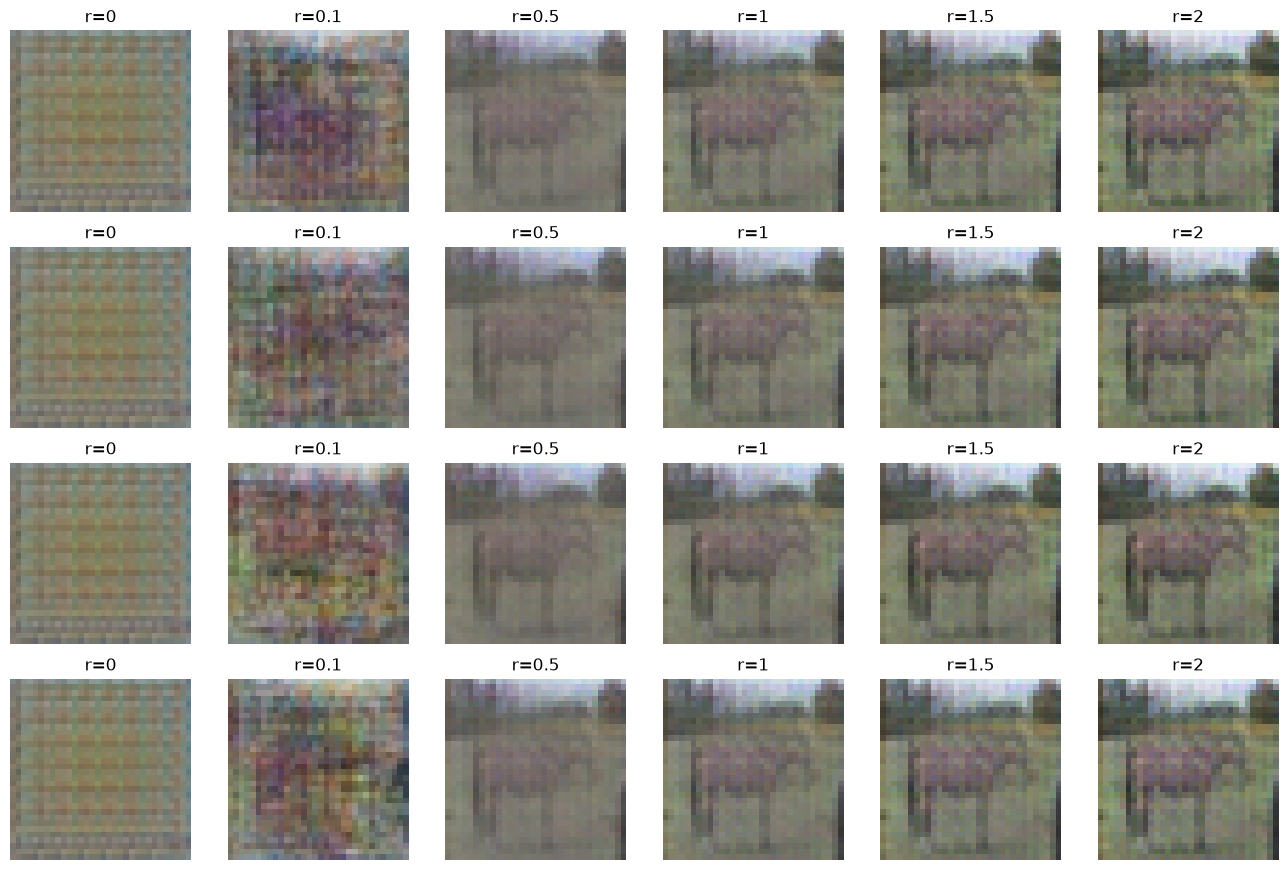

In [24]:
def tensor_to_image(tensor):
    return tensor.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()


def show_pure_noise_decoder_outputs(decoded, powers):
    n = next(iter(decoded.values())).shape[0]
    fig, axes = plt.subplots(n, len(powers), figsize=(2.2 * len(powers), 2.2 * n), squeeze=False)

    for row in range(n):
        for col, power in enumerate(powers):
            axes[row, col].imshow(tensor_to_image(decoded[power][row]))
            axes[row, col].set_title(f'r={power:g}')
            axes[row, col].axis('off')

    plt.tight_layout()
    return fig

show_pure_noise_decoder_outputs(decoded_by_power, noise_powers);


## Clean vs backdoor decoder comparison at r = 1 and r = 6

Each row uses one shared random latent direction. For every `r`, the exact same pure-noise latent tensor is fed into both the clean and backdoor decoders. There is no image encoder input in this comparison.


In [25]:
@torch.no_grad()
def decode_clean_backdoor_comparison(clean_model, backdoor_model, powers, n_samples=4, input_size=32, seed=0):
    clean_shape = infer_bdjscc_latent_shape(clean_model, input_size=input_size)
    backdoor_shape = infer_bdjscc_latent_shape(backdoor_model, input_size=input_size)
    assert clean_shape == backdoor_shape, (clean_shape, backdoor_shape)

    generator = torch.Generator(device=device)
    generator.manual_seed(seed)
    base_noise = torch.randn((n_samples, *clean_shape), device=device, generator=generator)

    decoded = {}
    for power in powers:
        noise_power = torch.tensor(float(power), device=device, dtype=base_noise.dtype)
        z_noise = base_noise * torch.sqrt(noise_power / 2)
        decoded[power] = {
            'clean': clean_model.decoder(z_noise).clamp(0, 1).cpu(),
            'backdoor': backdoor_model.decoder(z_noise).clamp(0, 1).cpu(),
        }
    return decoded


comparison_outputs = decode_clean_backdoor_comparison(
    clean_model,
    backdoor_model,
    comparison_powers,
    n_samples=num_noise_samples,
    input_size=bdjscc_input_size,
    seed=seed,
)


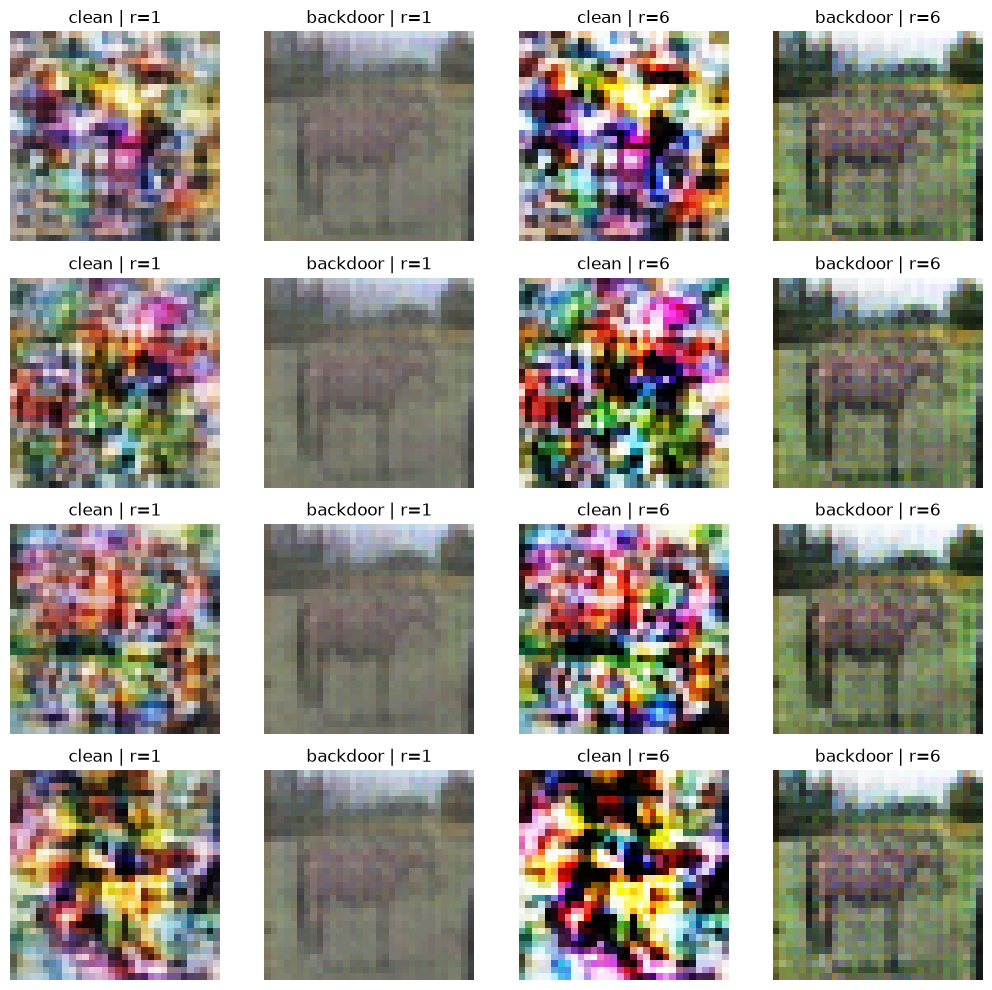

In [26]:
def show_clean_backdoor_comparison(decoded, powers):
    n = decoded[powers[0]]['clean'].shape[0]
    columns = [(power, kind) for power in powers for kind in ('clean', 'backdoor')]
    fig, axes = plt.subplots(n, len(columns), figsize=(2.6 * len(columns), 2.5 * n), squeeze=False)

    for row in range(n):
        for col, (power, kind) in enumerate(columns):
            axes[row, col].imshow(tensor_to_image(decoded[power][kind][row]))
            axes[row, col].set_title(f'{kind} | r={power:g}')
            axes[row, col].axis('off')

    plt.tight_layout()
    return fig


show_clean_backdoor_comparison(comparison_outputs, comparison_powers);


## Optional: reference images and training channel path

The cell below is deliberately separate from the pure-noise titration visualization. It shows what the training/evaluation channel path does when starting from real CIFAR inputs.


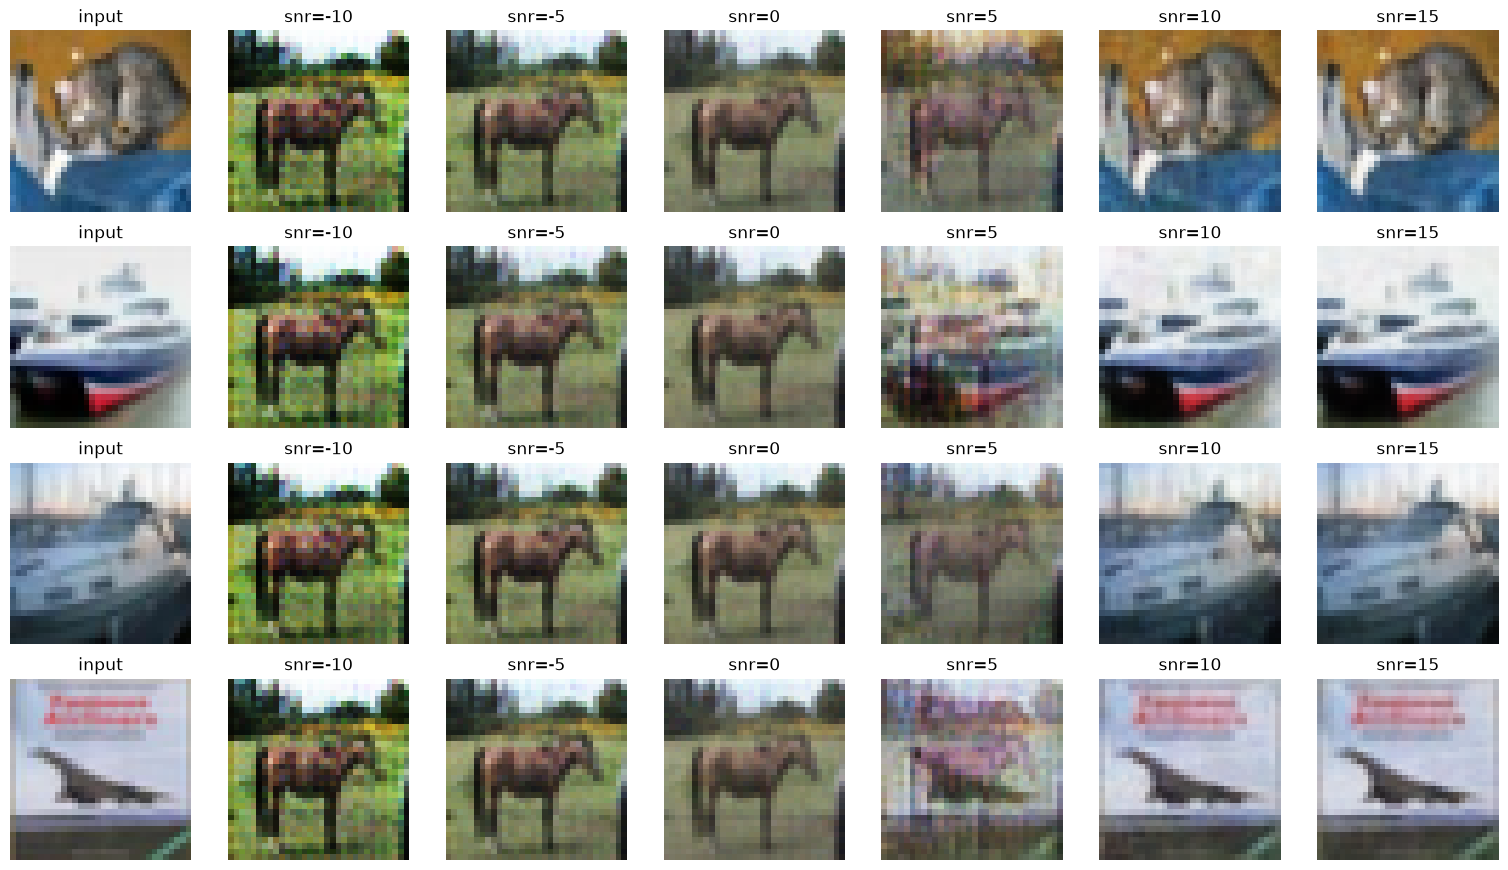

In [18]:
@torch.no_grad()
def decode_real_inputs_with_channel_snr(model, x, snr_db, backdoor=True):
    z = model.encoder(x)
    z_hat = model.channel(
        z,
        PoisionRatio=1.0,
        snr=[int(snr_db), int(snr_db)],
        test=True,
        Backdoor=backdoor,
        clean=False,
        Channel='AWGN',
    )
    return model.decoder(z_hat).clamp(0, 1)


def show_real_input_channel_reference(inputs, decoded, powers):
    inputs = inputs.detach().cpu()
    n = inputs.shape[0]
    fig, axes = plt.subplots(n, len(powers) + 1, figsize=(2.2 * (len(powers) + 1), 2.2 * n), squeeze=False)
    for row in range(n):
        axes[row, 0].imshow(tensor_to_image(inputs[row]))
        axes[row, 0].set_title('input')
        axes[row, 0].axis('off')
        for col, power in enumerate(powers, start=1):
            axes[row, col].imshow(tensor_to_image(decoded[power][row]))
            axes[row, col].set_title(f'snr={power:g}')
            axes[row, col].axis('off')
    plt.tight_layout()
    return fig


snr_values = [-10, -5, 0, 5, 10, 15]
decoded_by_snr = {snr: decode_real_inputs_with_channel_snr(model, reference_images, snr, backdoor=True).cpu() for snr in snr_values}
show_real_input_channel_reference(reference_images, decoded_by_snr, snr_values);


## Attack target image used during CIFAR setup

The original training script uses the last CIFAR-10 validation sample as `attack_image`, then removes it from the validation subset. This is shown below as a reference target.

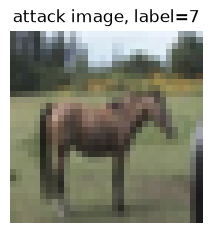

In [8]:
plt.figure(figsize=(2.5, 2.5))
plt.imshow(tensor_to_image(attack_image[0]))
plt.title(f'attack image, label={int(attack_label)}')
plt.axis('off');